# Video Classification From End to End: UCF101 → R3D-18

This notebook is deliberately small and explicit. You will see the complete training path:

**compressed video files → dataset manifest → validation/cleaning → frame sampling → spatial preprocessing → batches → 3D CNN → cross-entropy loss → backpropagation → evaluation → inference**

We use:
- a **10-class subset of UCF101** for action classification,
- **OpenCV** for CPU decoding of frames from compressed `.avi` videos,
- torchvision's pretrained **R3D-18** (3D ResNet-18),
- **16 sampled frames** per training example,
- **BF16 mixed precision** on your A100.

The model ultimately receives a tensor shaped **`[batch, channels, time, height, width]`** and outputs one logit vector per video clip.


## 1. Install the small set of libraries we need

In [1]:
# Colab already provides PyTorch, torchvision, pandas, NumPy, matplotlib, and OpenCV.
# Do NOT upgrade Colab's core scientific/CUDA stack in this notebook.
# We only install small pure-Python utilities that are not guaranteed to be present.
%pip install -q huggingface_hub scikit-learn tqdm

## 2. Imports, reproducibility, and GPU check

In [2]:
from pathlib import Path
import hashlib
import json
import math
import os
import random
import tarfile
import time

import matplotlib.pyplot as plt
import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torchvision
from torchvision.models.video import r3d_18, R3D_18_Weights

from huggingface_hub import hf_hub_download
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

assert torch.cuda.is_available(), "This notebook is intended for a CUDA GPU."
device = torch.device("cuda")

# Good default for fixed-ish input sizes.
torch.backends.cudnn.benchmark = True

# Avoid OpenCV creating its own large CPU thread pool inside DataLoader workers.
cv2.setNumThreads(0)

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("OpenCV:", cv2.__version__)
print("GPU:", torch.cuda.get_device_name(0))
print("BF16 supported:", torch.cuda.is_bf16_supported())


PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
OpenCV: 5.0.0
GPU: NVIDIA L4
BF16 supported: True


## 3. Download the dataset

We use the same small UCF101 archive referenced by Hugging Face's video-classification tutorial. The archive already contains `train/`, `val/`, and `test/` directories, each with one subdirectory per class.

In [3]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

repo_id = "sayakpaul/ucf101-subset"
filename = "UCF101_subset.tar.gz"

archive_path = Path(hf_hub_download(
    repo_id=repo_id,
    filename=filename,
    repo_type="dataset",
))
print("Downloaded:", archive_path)

extract_root = DATA_DIR
expected_root = extract_root / "UCF101_subset"

# Safe tar extraction: reject members trying to escape DATA_DIR.
def safe_extract_tar(tar_path: Path, destination: Path):
    destination = destination.resolve()
    with tarfile.open(tar_path, "r:*") as tf:
        for member in tf.getmembers():
            target = (destination / member.name).resolve()
            if destination != target and destination not in target.parents:
                raise RuntimeError(f"Unsafe archive path: {member.name}")
        tf.extractall(destination)

if not expected_root.exists():
    safe_extract_tar(archive_path, extract_root)

DATASET_ROOT = expected_root
print("Dataset root:", DATASET_ROOT.resolve())
print("Top-level folders:", sorted(p.name for p in DATASET_ROOT.iterdir() if p.is_dir()))

Downloaded: /root/.cache/huggingface/hub/datasets--sayakpaul--ucf101-subset/snapshots/b9984b8d2a95e4a1879e1b071e9433858d0bc24a/UCF101_subset.tar.gz
Dataset root: /content/data/UCF101_subset
Top-level folders: ['test', 'train', 'val']


## 4. Build a raw manifest

A **manifest** is just a table saying what every example is, where its file lives, which split it belongs to, and what its label is.

This is a very common pattern in ML pipelines because it makes data problems visible before training begins.

In [4]:
VIDEO_EXTENSIONS = {".avi", ".mp4", ".mov", ".mkv", ".webm"}
rows = []

for split in ["train", "val", "test"]:
    split_dir = DATASET_ROOT / split
    for class_dir in sorted(p for p in split_dir.iterdir() if p.is_dir()):
        for path in sorted(class_dir.iterdir()):
            if path.suffix.lower() in VIDEO_EXTENSIONS:
                rows.append({
                    "split": split,
                    "label_name": class_dir.name,
                    "path": str(path),
                    "bytes": path.stat().st_size,
                })

raw_df = pd.DataFrame(rows)
print("Videos found:", len(raw_df))
display(raw_df.head())

print("\nVideos per split:")
display(raw_df.groupby("split").size().rename("count").to_frame())

print("\nClass counts by split:")
display(pd.crosstab(raw_df["label_name"], raw_df["split"]))

Videos found: 405


,split,label_name,path,bytes
0,train,ApplyEyeMakeup,data/UCF101_subset/train/ApplyEyeMakeup/v_Appl...,374406
1,train,ApplyEyeMakeup,data/UCF101_subset/train/ApplyEyeMakeup/v_Appl...,279230
2,train,ApplyEyeMakeup,data/UCF101_subset/train/ApplyEyeMakeup/v_Appl...,404490
3,train,ApplyEyeMakeup,data/UCF101_subset/train/ApplyEyeMakeup/v_Appl...,217834
4,train,ApplyEyeMakeup,data/UCF101_subset/train/ApplyEyeMakeup/v_Appl...,406788



Videos per split:


,count
split,
test,75
train,300
val,30



Class counts by split:


split,test,train,val
label_name,,,
ApplyEyeMakeup,6,30,3
ApplyLipstick,4,30,3
Archery,7,30,3
BabyCrawling,9,30,3
BalanceBeam,4,30,3
BandMarching,9,30,3
BaseballPitch,10,30,3
Basketball,11,30,3
BasketballDunk,6,30,3


## 5. Validate and clean every video

For each file we:
1. make sure OpenCV can open it,
2. make sure it reports frames,
3. decode three probe frames (start/middle/end),
4. collect metadata such as resolution, FPS, duration, and codec,
5. compute a SHA-1 hash so we can detect exact duplicate files.

We do **not delete** bad files. We keep a manifest and filter invalid rows. That makes the cleaning step reproducible.


In [5]:
def sha1_file(path: str, chunk_size: int = 1024 * 1024) -> str:
    h = hashlib.sha1()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()


def _decode_one_cv2(cap: cv2.VideoCapture, frame_index: int):
    """Seek to one frame, decode it, and return RGB uint8 [C,H,W]."""
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_index))
    ok, frame_bgr = cap.read()
    if not ok or frame_bgr is None:
        raise ValueError(f"could not decode frame {frame_index}")
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    return torch.from_numpy(frame_rgb).permute(2, 0, 1).contiguous()


def decode_frames_cv2(path: str, indices: list[int]) -> torch.Tensor:
    """Decode selected video frames -> uint8 tensor [T,C,H,W]."""
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        cap.release()
        raise ValueError(f"OpenCV could not open: {path}")

    try:
        # Cache duplicate indices (useful for very short videos).
        cache = {}
        frames = []
        for idx in indices:
            idx = int(idx)
            if idx not in cache:
                cache[idx] = _decode_one_cv2(cap, idx)
            frames.append(cache[idx])
        return torch.stack(frames, dim=0)
    finally:
        cap.release()


def inspect_video(path: str) -> dict:
    out = {
        "valid": False,
        "error": None,
        "num_frames": None,
        "fps": None,
        "duration_s": None,
        "width": None,
        "height": None,
        "codec": None,
        "sha1": None,
    }

    cap = cv2.VideoCapture(str(path))
    try:
        if not cap.isOpened():
            raise ValueError("OpenCV could not open video")

        n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps = float(cap.get(cv2.CAP_PROP_FPS))
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        if n <= 0:
            raise ValueError("video reports zero frames")

        # Decode three actual frames so metadata alone cannot mark a corrupt file valid.
        probe_indices = sorted(set([0, n // 2, n - 1]))
        for idx in probe_indices:
            frame = _decode_one_cv2(cap, idx)
            if frame.ndim != 3 or frame.shape[0] != 3:
                raise ValueError(f"unexpected decoded shape: {tuple(frame.shape)}")

        fourcc_int = int(cap.get(cv2.CAP_PROP_FOURCC))
        codec = "".join(chr((fourcc_int >> (8 * i)) & 0xFF) for i in range(4)).strip("\x00")

        out.update({
            "valid": True,
            "num_frames": n,
            "fps": fps if fps > 0 else None,
            "duration_s": (n / fps) if fps > 0 else None,
            "width": width if width > 0 else None,
            "height": height if height > 0 else None,
            "codec": codec or None,
            "sha1": sha1_file(path),
        })
    except Exception as e:
        out["error"] = repr(e)
    finally:
        cap.release()

    return out


inspection = []
for row in tqdm(raw_df.itertuples(index=False), total=len(raw_df), desc="Validating videos"):
    inspection.append(inspect_video(row.path))

inspect_df = pd.DataFrame(inspection)
df = pd.concat([raw_df.reset_index(drop=True), inspect_df], axis=1)

print("Valid:", int(df["valid"].sum()), "/", len(df))
if (~df["valid"]).any():
    display(df.loc[~df["valid"], ["split", "label_name", "path", "error"]])

clean_df = df[df["valid"]].copy().reset_index(drop=True)
display(clean_df[["split", "label_name", "num_frames", "fps", "duration_s", "width", "height", "codec"]].describe(include="all"))


Validating videos:   0%|          | 0/405 [00:00<?, ?it/s]

Valid: 400 / 405


,split,label_name,path,error
180,train,BaseballPitch,data/UCF101_subset/train/BaseballPitch/v_Baseb...,ValueError('could not decode frame 93')
225,train,Basketball,data/UCF101_subset/train/Basketball/v_Basketba...,ValueError('could not decode frame 299')
230,train,Basketball,data/UCF101_subset/train/Basketball/v_Basketba...,ValueError('could not decode frame 517')
231,train,Basketball,data/UCF101_subset/train/Basketball/v_Basketba...,ValueError('could not decode frame 345')
318,val,BaseballPitch,data/UCF101_subset/val/BaseballPitch/v_Basebal...,ValueError('could not decode frame 137')


,split,label_name,num_frames,fps,duration_s,width,height,codec
count,400,400,400.000000,400.000000,400.000000,400.0,400.0,400
unique,3,10,NaN,NaN,NaN,NaN,NaN,1
top,train,BandMarching,NaN,NaN,NaN,NaN,NaN,FMP4
freq,296,42,NaN,NaN,NaN,NaN,NaN,400
mean,NaN,NaN,143.602500,26.018856,5.588034,320.0,240.0,NaN
std,NaN,NaN,72.358405,2.008922,2.938659,0.0,0.0,NaN
min,NaN,NaN,37.000000,25.000000,1.480000,320.0,240.0,NaN
25%,NaN,NaN,93.750000,25.000000,3.480000,320.0,240.0,NaN
50%,NaN,NaN,124.000000,25.000000,4.765717,320.0,240.0,NaN
75%,NaN,NaN,175.250000,25.000000,6.875150,320.0,240.0,NaN


### Check for exact duplicates and train/validation/test leakage

In [6]:
dup_groups = clean_df[clean_df.duplicated("sha1", keep=False)].sort_values("sha1")

if len(dup_groups) == 0:
    print("No exact duplicate video files found.")
else:
    print("Duplicate files found:")
    display(dup_groups[["split", "label_name", "path", "sha1"]])

cross_split_leaks = []
for sha1, group in clean_df.groupby("sha1"):
    if group["split"].nunique() > 1:
        cross_split_leaks.append(group)

if cross_split_leaks:
    leaks = pd.concat(cross_split_leaks)
    display(leaks[["split", "label_name", "path", "sha1"]])
    raise RuntimeError("Exact duplicate video appears in more than one split. Fix leakage before training.")
else:
    print("No exact cross-split leakage detected.")

No exact duplicate video files found.
No exact cross-split leakage detected.


## 6. Create the label mapping and persist the clean manifest

The human-readable class name becomes an integer ID because cross-entropy expects integer class targets.

In [7]:
train_classes = sorted(clean_df.loc[clean_df.split == "train", "label_name"].unique())
assert set(train_classes) == set(clean_df.loc[clean_df.split == "val", "label_name"].unique())
assert set(train_classes) == set(clean_df.loc[clean_df.split == "test", "label_name"].unique())

label2id = {name: i for i, name in enumerate(train_classes)}
id2label = {i: name for name, i in label2id.items()}
clean_df["label"] = clean_df["label_name"].map(label2id).astype(int)

print("Classes:")
print(json.dumps(label2id, indent=2))

MANIFEST_PATH = DATA_DIR / "ucf101_10class_clean_manifest.csv"
clean_df.to_csv(MANIFEST_PATH, index=False)
print("Saved manifest to:", MANIFEST_PATH)

Classes:
{
  "ApplyEyeMakeup": 0,
  "ApplyLipstick": 1,
  "Archery": 2,
  "BabyCrawling": 3,
  "BalanceBeam": 4,
  "BandMarching": 5,
  "BaseballPitch": 6,
  "Basketball": 7,
  "BasketballDunk": 8,
  "BenchPress": 9
}
Saved manifest to: data/ucf101_10class_clean_manifest.csv


## 7. Look at the actual video frames before building the model

A video is a time-ordered stack of images. We will sample 16 frames from each video and preserve their order.

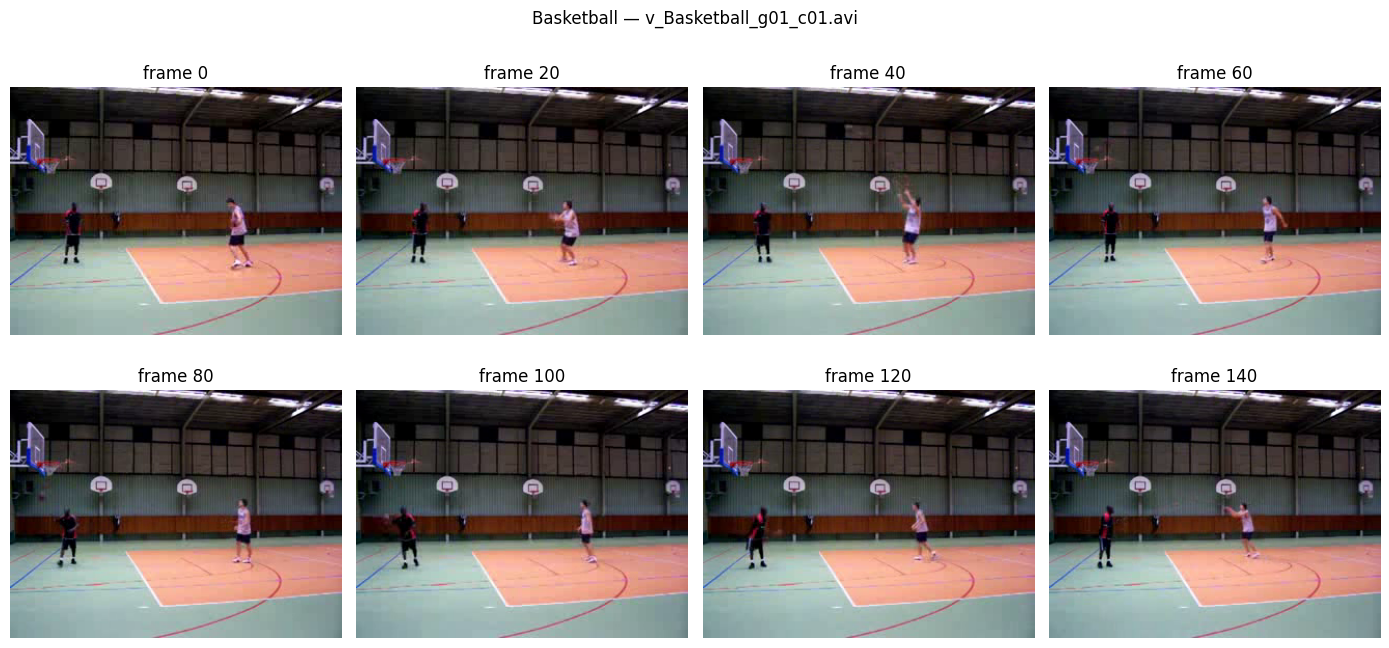

Decoded tensor shape: (8, 3, 240, 320) = [time, channels, height, width]


In [8]:
def evenly_spaced_indices(n_frames: int, num_samples: int = 8):
    return np.linspace(0, max(0, n_frames - 1), num_samples).round().astype(int).tolist()

sample_row = clean_df.sample(1, random_state=SEED).iloc[0]
indices = evenly_spaced_indices(int(sample_row.num_frames), 8)
frames = decode_frames_cv2(sample_row.path, indices)  # [T,C,H,W], uint8

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, frame, idx in zip(axes.flat, frames, indices):
    ax.imshow(frame.permute(1, 2, 0).numpy())
    ax.set_title(f"frame {idx}")
    ax.axis("off")
plt.suptitle(f"{sample_row.label_name} — {Path(sample_row.path).name}")
plt.tight_layout()
plt.show()

print("Decoded tensor shape:", tuple(frames.shape), "= [time, channels, height, width]")


## 8. Frame sampling and preprocessing

The pretrained R3D-18 weights use short 16-frame clips and 112×112 spatial crops.

For each training sample we:
- choose a **random temporal window**,
- sample every `FRAME_STRIDE`-th frame,
- resize frames,
- take a random 112×112 crop,
- optionally flip horizontally,
- scale pixels to `[0, 1]`,
- normalize with the pretrained model's mean/std,
- rearrange to **`[C, T, H, W]`**.

Validation/test use deterministic center sampling and center crops.

In [9]:
NUM_FRAMES = 16
FRAME_STRIDE = 2
RESIZE_H, RESIZE_W = 128, 171
CROP_SIZE = 112

# R3D-18 / Kinetics-400 normalization from torchvision's pretrained weights.
MEAN = torch.tensor([0.43216, 0.394666, 0.37645]).view(1, 3, 1, 1)
STD = torch.tensor([0.22803, 0.22145, 0.216989]).view(1, 3, 1, 1)


def sample_clip_indices(n_frames: int, training: bool) -> list[int]:
    needed_span = 1 + (NUM_FRAMES - 1) * FRAME_STRIDE

    if n_frames >= needed_span:
        max_start = n_frames - needed_span
        start = random.randint(0, max_start) if training else max_start // 2
        return [start + i * FRAME_STRIDE for i in range(NUM_FRAMES)]

    # Short-video fallback: spread 16 indices over all available frames.
    return np.linspace(0, max(0, n_frames - 1), NUM_FRAMES).round().astype(int).tolist()


def spatial_preprocess(frames: torch.Tensor, training: bool) -> torch.Tensor:
    # Input: [T, C, H, W], uint8
    x = frames.float() / 255.0
    x = F.interpolate(x, size=(RESIZE_H, RESIZE_W), mode="bilinear", align_corners=False)

    if training:
        top = random.randint(0, RESIZE_H - CROP_SIZE)
        left = random.randint(0, RESIZE_W - CROP_SIZE)
        x = x[:, :, top:top + CROP_SIZE, left:left + CROP_SIZE]
        if random.random() < 0.5:
            x = torch.flip(x, dims=[3])
    else:
        top = (RESIZE_H - CROP_SIZE) // 2
        left = (RESIZE_W - CROP_SIZE) // 2
        x = x[:, :, top:top + CROP_SIZE, left:left + CROP_SIZE]

    x = (x - MEAN) / STD
    x = x.permute(1, 0, 2, 3).contiguous()  # [C, T, H, W]
    return x

## 9. Build a PyTorch `Dataset`

In [10]:
class UCFClipDataset(Dataset):
    def __init__(self, manifest: pd.DataFrame, split: str):
        self.df = manifest[manifest.split == split].reset_index(drop=True)
        self.training = split == "train"

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]

        indices = sample_clip_indices(int(row.num_frames), training=self.training)
        frames = decode_frames_cv2(row.path, indices)
        clip = spatial_preprocess(frames, training=self.training)

        return {
            "video": clip,                         # float32 [C,T,H,W]
            "label": torch.tensor(row.label, dtype=torch.long),
            "path": row.path,
        }

train_ds = UCFClipDataset(clean_df, "train")
val_ds = UCFClipDataset(clean_df, "val")
test_ds = UCFClipDataset(clean_df, "test")

print("train / val / test:", len(train_ds), len(val_ds), len(test_ds))

example = train_ds[0]
print("One model input:", tuple(example["video"].shape), example["video"].dtype)
print("Label:", example["label"].item(), "->", id2label[example["label"].item()])


train / val / test: 296 29 75
One model input: (3, 16, 112, 112) torch.float32
Label: 0 -> ApplyEyeMakeup


## 10. DataLoaders = batch construction

A DataLoader calls `Dataset.__getitem__()` many times, combines examples into batches, and uses worker processes to decode videos in parallel on the CPU. The A100 is reserved for the model forward/backward pass.


In [11]:
BATCH_SIZE = 16
NUM_WORKERS = min(8, max(2, (os.cpu_count() or 4) // 2))

loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
)

train_loader = DataLoader(train_ds, shuffle=True, drop_last=False, **loader_kwargs)
val_loader = DataLoader(val_ds, shuffle=False, drop_last=False, **loader_kwargs)
test_loader = DataLoader(test_ds, shuffle=False, drop_last=False, **loader_kwargs)

batch = next(iter(train_loader))
print("Batch video shape:", tuple(batch["video"].shape), "= [B, C, T, H, W]")
print("Batch label shape:", tuple(batch["label"].shape))

Batch video shape: (16, 3, 16, 112, 112) = [B, C, T, H, W]
Batch label shape: (16,)


## 11. Create the video model

R3D-18 is a ResNet where the convolutions operate in **time + height + width** instead of only height + width.

We load Kinetics-400 pretrained weights and replace the final classifier with a new 10-class linear layer.

In [12]:
weights = R3D_18_Weights.DEFAULT
model = r3d_18(weights=None) # changed to None to train from scratch
model.fc = nn.Linear(model.fc.in_features, len(label2id))
model = model.to(device)

num_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {num_params/1e6:.2f}M")
print(f"Trainable:  {trainable_params/1e6:.2f}M")
print(model.fc)

# Sanity-check one forward pass.
with torch.no_grad(), torch.autocast(device_type="cuda", dtype=torch.bfloat16):
    logits = model(batch["video"].to(device, non_blocking=True))
print("Logits shape:", tuple(logits.shape), "= [batch, num_classes]")

Parameters: 33.17M
Trainable:  33.17M
Linear(in_features=512, out_features=10, bias=True)
Logits shape: (16, 10) = [batch, num_classes]


## 12. Loss, optimizer, and evaluation function

For single-label classification:
- the model emits **logits**,
- `CrossEntropyLoss` compares those logits against the integer class label,
- `loss.backward()` computes gradients,
- `AdamW.step()` updates the weights.

We use BF16 autocast because the A100 supports it well and it reduces memory/compute cost.

In [13]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # label smoothing doesnt always say that this class is finally correct, instead say, highest chances of this.
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4) # Increased lr from 1e-4 for bigger updates
EPOCHS = 10 # increased from 5
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, leave=False):
            videos = batch["video"].to(device, non_blocking=True)
            labels = batch["label"].to(device, non_blocking=True)

            with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                logits = model(videos)
                loss = criterion(logits, labels)

            total_loss += loss.item() * videos.size(0)
            all_preds.extend(logits.argmax(dim=1).cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, all_labels, all_preds

## 13. Train the model

In [14]:
history = []
best_val_acc = -1.0
best_path = Path("best_r3d18_ucf101_10class.pt")

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    correct = 0
    seen = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")
    for batch in pbar:
        videos = batch["video"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            logits = model(videos)
            loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        batch_size = videos.size(0)
        running_loss += loss.item() * batch_size
        correct += (logits.argmax(1) == labels).sum().item()
        seen += batch_size

        pbar.set_postfix(
            loss=f"{running_loss/seen:.3f}",
            acc=f"{correct/seen:.3f}",
            lr=f"{optimizer.param_groups[0]['lr']:.2e}",
        )

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = correct / len(train_loader.dataset)
    val_loss, val_acc, _, _ = evaluate(model, val_loader)
    scheduler.step()

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })

    print(
        f"epoch={epoch} | "
        f"train loss={train_loss:.4f}, acc={train_acc:.3f} | "
        f"val loss={val_loss:.4f}, acc={val_acc:.3f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "model_state_dict": model.state_dict(),
            "label2id": label2id,
            "id2label": id2label,
            "epoch": epoch,
            "val_acc": val_acc,
        }, best_path)
        print("  saved new best checkpoint ->", best_path)

print("Best validation accuracy:", best_val_acc)

Epoch 1/10:   0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

epoch=1 | train loss=2.1881, acc=0.223 | val loss=2.1557, acc=0.241
  saved new best checkpoint -> best_r3d18_ucf101_10class.pt


Epoch 2/10:   0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

...

  0%|          | 0/2 [00:00<?, ?it/s]

epoch=9 | train loss=1.0630, acc=0.807 | val loss=1.4750, acc=0.414


Epoch 10/10:   0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

epoch=10 | train loss=0.9903, acc=0.814 | val loss=1.4508, acc=0.552
Best validation accuracy: 0.6206896551724138


## 14. Plot the learning curves

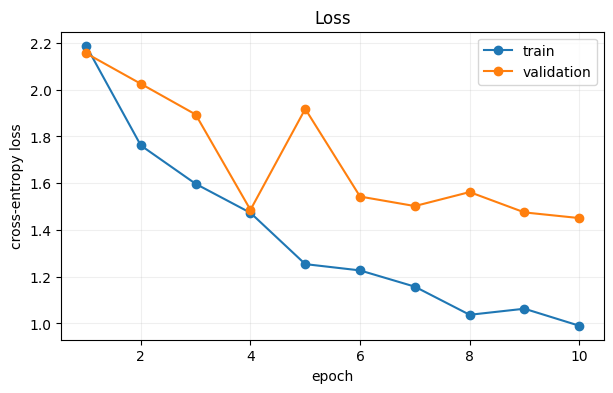

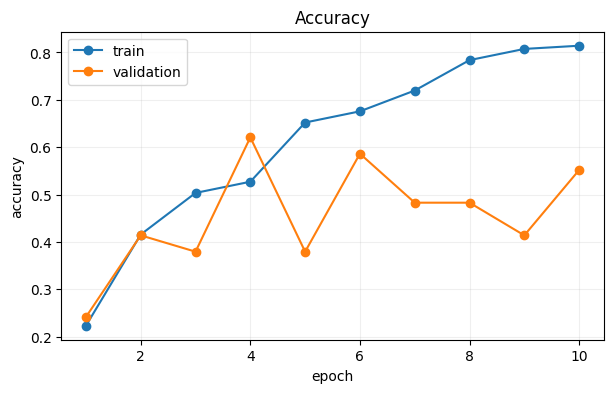

In [15]:
hist = pd.DataFrame(history)

plt.figure(figsize=(7, 4))
plt.plot(hist.epoch, hist.train_loss, marker="o", label="train")
plt.plot(hist.epoch, hist.val_loss, marker="o", label="validation")
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.title("Loss")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(hist.epoch, hist.train_acc, marker="o", label="train")
plt.plot(hist.epoch, hist.val_acc, marker="o", label="validation")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Accuracy")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 15. Evaluate once on the held-out test split

  0%|          | 0/5 [00:00<?, ?it/s]

Test loss: 1.4257
Test accuracy: 0.613

Classification report:

                precision    recall  f1-score   support

ApplyEyeMakeup      0.429     1.000     0.600         6
 ApplyLipstick      0.000     0.000     0.000         4
       Archery      1.000     0.143     0.250         7
  BabyCrawling      0.667     0.222     0.333         9
   BalanceBeam      0.400     0.500     0.444         4
  BandMarching      0.714     0.556     0.625         9
 BaseballPitch      1.000     1.000     1.000        10
    Basketball      0.857     0.545     0.667        11
BasketballDunk      0.667     1.000     0.800         6
    BenchPress      0.471     0.889     0.615         9

      accuracy                          0.613        75
     macro avg      0.620     0.585     0.533        75
  weighted avg      0.684     0.613     0.579        75



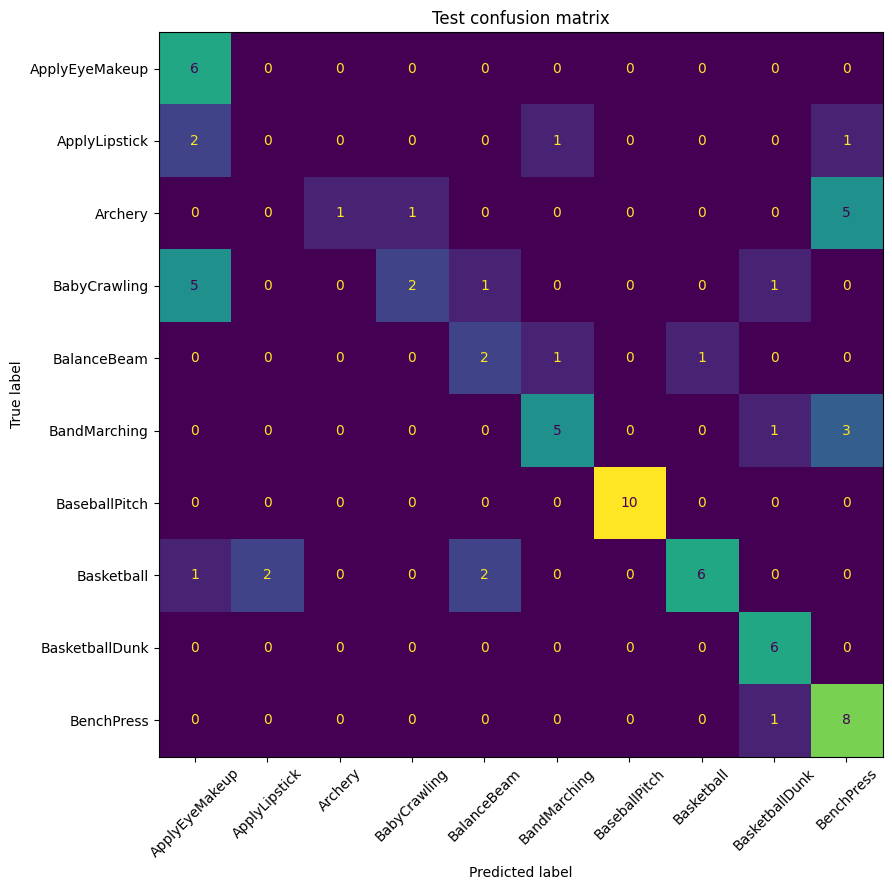

In [16]:
checkpoint = torch.load(best_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.3f}")

names = [id2label[i] for i in range(len(id2label))]
print("\nClassification report:\n")
print(classification_report(y_true, y_pred, target_names=names, digits=3, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(names))))
fig, ax = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay(cm, display_labels=names).plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Test confusion matrix")
plt.tight_layout()
plt.show()

## 16. Run inference on one individual video

During inference we use deterministic center temporal sampling + center crop, then convert logits to probabilities with softmax.

File: data/UCF101_subset/test/BabyCrawling/v_BabyCrawling_g22_c02.avi
Ground truth: BabyCrawling
Predictions:
  ApplyEyeMakeup            0.380
  ApplyLipstick             0.245
  BabyCrawling              0.216


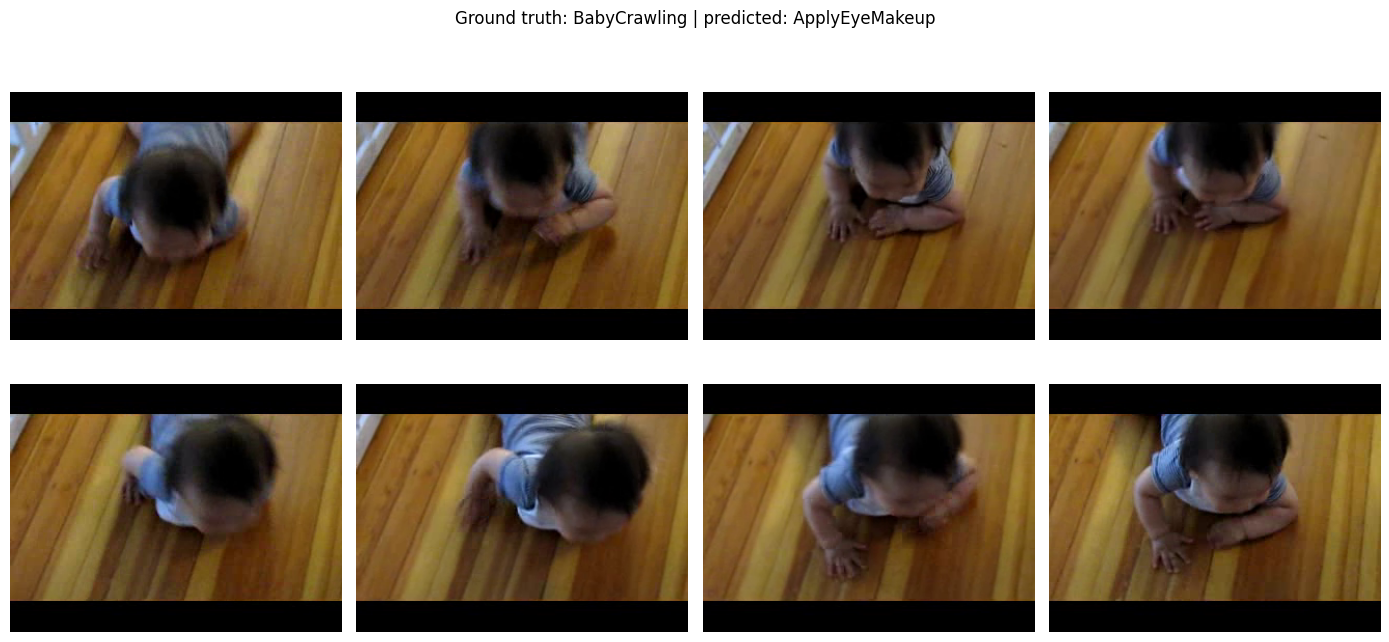

In [17]:
@torch.no_grad()
def predict_video(path: str, topk: int = 3):
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise ValueError(f"OpenCV could not open {path}")
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    indices = sample_clip_indices(n_frames, training=False)
    frames = decode_frames_cv2(path, indices)
    clip = spatial_preprocess(frames, training=False).unsqueeze(0).to(device)

    model.eval()
    with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        logits = model(clip)
    probs = logits.float().softmax(dim=1)[0]

    values, indices_top = probs.topk(topk)
    return [(id2label[i.item()], float(v.item())) for v, i in zip(values, indices_top)], frames

row = clean_df[clean_df.split == "test"].sample(1, random_state=123).iloc[0]
preds, sampled_frames = predict_video(row.path)

print("File:", row.path)
print("Ground truth:", row.label_name)
print("Predictions:")
for name, prob in preds:
    print(f"  {name:25s} {prob:.3f}")

show_idx = np.linspace(0, len(sampled_frames) - 1, 8).round().astype(int)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, idx in zip(axes.flat, show_idx):
    frame = sampled_frames[idx]
    ax.imshow(frame.permute(1, 2, 0).cpu().numpy())
    ax.axis("off")
plt.suptitle(f"Ground truth: {row.label_name} | predicted: {preds[0][0]}")
plt.tight_layout()
plt.show()


## 17. Save a compact inference checkpoint

In [26]:
FINAL_PATH = Path("r3d18_ucf101_10class_final.pt")
torch.save({
    "model_state_dict": model.state_dict(),
    "label2id": label2id,
    "id2label": id2label,
    "num_frames": NUM_FRAMES,
    "frame_stride": FRAME_STRIDE,
    "resize": [RESIZE_H, RESIZE_W],
    "crop_size": CROP_SIZE,
    "mean": MEAN.flatten().tolist(),
    "std": STD.flatten().tolist(),
}, FINAL_PATH)
print("Saved:", FINAL_PATH.resolve())

Saved: /content/r3d18_ucf101_10class_final.pt


## 18. Optional experiment: train from scratch

Do this **after** the pretrained run works.

Change model creation to:

```python
model = r3d_18(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(label2id))
model = model.to(device)
```

Keep everything else approximately the same, but train for more epochs. On this tiny dataset you should expect training from scratch to be substantially harder and more prone to overfitting. That comparison is one of the most useful lessons in this notebook.

# Mental model: what just happened?

For one training example:

1. **Video file**: compressed bytes on disk.
2. **Decode**: retrieve RGB frames.
3. **Temporal sampling**: choose 16 ordered frames.
4. **Spatial transform**: resize/crop/flip/normalize each frame consistently.
5. **Clip tensor**: `[3, 16, 112, 112]`.
6. **Batch**: `[B, 3, 16, 112, 112]`.
7. **3D CNN**: learns spatial + temporal features.
8. **Classifier**: outputs `[B, 10]` logits.
9. **Cross entropy**: compares logits with class IDs.
10. **Backpropagation**: computes gradients through all trainable layers.
11. **Optimizer**: changes weights to reduce future loss.
12. **Validation/test**: same forward path, but no gradient updates and no random augmentation.

That is the core pattern behind supervised video classification. Larger systems mainly change the model architecture, sampling strategy, augmentations, scale of the dataset, and distributed-training machinery.

## Official references

- Torchvision R3D-18: https://docs.pytorch.org/vision/main/models/generated/torchvision.models.video.r3d_18.html
- OpenCV VideoCapture: https://docs.opencv.org/4.x/d8/dfe/classcv_1_1VideoCapture.html
- Torchvision video transforms: https://docs.pytorch.org/vision/main/transforms.html
- Hugging Face video classification tutorial / UCF101 subset: https://huggingface.co/docs/transformers/main/tasks/video_classification
- PyTorch AMP: https://docs.pytorch.org/docs/main/amp.html
